# Phase 5.2: LOSO CV -- Semua Model x 5 Dataset

**Tujuan:** Menjalankan LOSO CV (15 fold, lihat 5.1) untuk 5 dataset kunci x 4 model dasar
(LDA, SVM_Tuned, RF_Tuned, XGBoost_Tuned) + Voting_Soft (rata-rata `predict_proba` 4 model dasar,
tanpa fit tambahan).

**Hyperparameter model** memakai hasil tuning Phase 4.6 (`tuning_best_params.csv`) -- **tidak**
re-tuning (GridSearchCV) di sini. Alasan: (1) re-tuning di 15 fold LOSO jauh lebih mahal dari 5 fold
grouped-CV Phase 4, (2) memilih hyperparameter dari fold yang sama dengan evaluasi akhir = double-dip
(optimistic bias) -- hyperparameter yang sudah dipilih via CV terpisah (Phase 4) lebih valid dipakai
sebagai fixed setting untuk evaluasi independen ini.

**Stacking** (dipakai di Phase 4) **di-skip** di LOSO: butuh internal CV bersarang per base estimator
(cv=3 di Phase 4), yang pada 15 fold luar berarti 15 x 3 x 4 = 180 fit tambahan per dataset -- terlalu
mahal untuk manfaat marginal (di 4.7, Stacking tidak signifikan lebih baik dari Voting_Soft/model
tunggal tuned).

**Checkpointing per fold**: proses ini sudah pernah dijalankan penuh sebelumnya (background job
sempat mati 2x di 4.5/4.6 karena resource kill saat run paralel -- pelajaran itu diterapkan di sini
sejak awal). Jika sel di bawah dijalankan ulang, ia akan **skip** kombinasi (dataset, fold) yang
sudah tersimpan di `output/loso_cv_scores.csv` dan cuma menampilkan hasil final.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.facecolor'] = 'white'

PHASE3_CSV_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\csv"
ROI_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\3.4_roi_aggregation\output"
TUNING_PARAMS_CSV = r"D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\output\tuning_best_params.csv"
BASE = r"D:\Skripsi\new_data\phase_5_loso"
KEY_COLS = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']

def _feature_cols(df):
    exclude = KEY_COLS + [c for c in df.columns if 'hub_channel' in c]
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    return [c for c in cols if df[c].std() > 1e-10]

print("Setup OK.")

Setup OK.


In [2]:
from sklearn.feature_selection import f_classif

df_gc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_gc.csv"))
df_combined = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_combined.csv"))
df_spectral = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_spectral.csv"))
df_roi_all = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_all.csv"))  # GC_ROI+PDC_ROI(6-band)+Spectral

# Best PDC band by mean ANOVA F-score (konsisten dengan pola Phase 4)
pdc_files = [f for f in os.listdir(PHASE3_CSV_DIR)
             if f.startswith("engineered_features_pdc_") and "broadband" not in f]
best_pdc, best_pdc_name, best_score = None, None, -1
for f in pdc_files:
    df_pdc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, f))
    band = f.replace("engineered_features_pdc_", "").replace(".csv", "")
    feat_cols = _feature_cols(df_pdc)
    f_scores, _ = f_classif(df_pdc[feat_cols].fillna(0).values, df_pdc['class'].values)
    score = np.nanmean(f_scores)
    if score > best_score:
        best_score, best_pdc, best_pdc_name = score, df_pdc, f"PDC_{band.title()}"

DATASETS_RAW = {
    'GC': df_gc,
    best_pdc_name: best_pdc,
    'Spectral': df_spectral,
    'Combined': df_combined,
    'GC+PDC_ROI+Spectral': df_roi_all,
}

def prepare_features(df, normalize=True):
    feature_cols = _feature_cols(df)
    df_use = df.copy()
    if normalize:
        grp = df_use.groupby('subject_id')[feature_cols]
        mean = grp.transform('mean')
        std = grp.transform('std').replace(0, np.nan)
        df_use[feature_cols] = (df_use[feature_cols] - mean) / std
    X = df_use[feature_cols].fillna(0).values
    y = df['class'].values
    groups = df['subject_num'].values
    return X, y, groups, feature_cols

datasets = {}
for name, df in DATASETS_RAW.items():
    X, y, groups, features = prepare_features(df, normalize=True)
    datasets[name] = {'X': X, 'y': y, 'groups': groups, 'features': features, 'df': df}
    print(f"{name:24s}: X={X.shape}, subjects={len(np.unique(groups))}, trials/subject={len(y)//len(np.unique(groups))}")

GC                      : X=(675, 282), subjects=15, trials/subject=45


PDC_Theta               : X=(675, 282), subjects=15, trials/subject=45


Spectral                : X=(675, 640), subjects=15, trials/subject=45


Combined                : X=(675, 2614), subjects=15, trials/subject=45


GC+PDC_ROI+Spectral     : X=(675, 990), subjects=15, trials/subject=45


In [3]:
DIR_52 = os.path.join(BASE, "5.2_loso_all_models", "output")
os.makedirs(DIR_52, exist_ok=True)

df_tuned = pd.read_csv(TUNING_PARAMS_CSV)
df_tuned['Best_Params'] = df_tuned['Best_Params'].apply(ast.literal_eval)

def get_tuned_params(dataset_name, model_name, default):
    row = df_tuned[(df_tuned['Dataset'] == dataset_name) & (df_tuned['Model'] == model_name)]
    if len(row) == 0:
        print(f"  [WARN] No tuned params for ({dataset_name}, {model_name}), using default {default}")
        return default
    return row.iloc[0]['Best_Params']

print(f"Loaded {len(df_tuned)} tuned hyperparameter rows from Phase 4.6.")

Loaded 33 tuned hyperparameter rows from Phase 4.6.


In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

def build_models(dataset_name, n_features):
    k = min(1200, n_features)
    svm_p = get_tuned_params(dataset_name, 'SVM_Tuned', {'clf__C': 1, 'clf__gamma': 'scale'})
    rf_p = get_tuned_params(dataset_name, 'RF_Tuned', {'clf__n_estimators': 200, 'clf__max_depth': 10})
    xgb_p = get_tuned_params(dataset_name, 'XGBoost_Tuned',
                              {'clf__n_estimators': 200, 'clf__max_depth': 6, 'clf__learning_rate': 0.05})
    models = {
        'LDA': Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                          ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))]),
        'SVM_Tuned': Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                                ('clf', SVC(kernel='rbf', probability=True,
                                            C=svm_p['clf__C'], gamma=svm_p['clf__gamma']))]),
        'RF_Tuned': Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                               ('clf', RandomForestClassifier(random_state=42, n_jobs=-1,
                                       n_estimators=rf_p['clf__n_estimators'], max_depth=rf_p['clf__max_depth']))]),
    }
    if HAS_XGB:
        models['XGBoost_Tuned'] = Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                                             ('clf', XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1,
                                                     n_estimators=xgb_p['clf__n_estimators'],
                                                     max_depth=xgb_p['clf__max_depth'],
                                                     learning_rate=xgb_p['clf__learning_rate']))])
    return models

print("Model builder ready:", list(build_models('Combined', 2676).keys()) + ['Voting_Soft'])

Model builder ready: ['LDA', 'SVM_Tuned', 'RF_Tuned', 'XGBoost_Tuned', 'Voting_Soft']


In [5]:
CKPT_FOLD = os.path.join(DIR_52, 'loso_cv_scores.csv')
CKPT_SUBJECT = os.path.join(DIR_52, 'loso_per_subject.csv')

fold_rows = pd.read_csv(CKPT_FOLD).to_dict('records') if os.path.exists(CKPT_FOLD) else []
subj_rows = pd.read_csv(CKPT_SUBJECT).to_dict('records') if os.path.exists(CKPT_SUBJECT) else []
done_dataset_folds = set((r['Dataset'], r['Fold']) for r in subj_rows)

print(f"Checkpoint: {len(done_dataset_folds)} (dataset, fold) unit(s) already done, resuming...")
logo = LeaveOneGroupOut()

for name, d in datasets.items():
    X, y, groups = d['X'], d['y'], d['groups']
    n_folds = logo.get_n_splits(groups=groups)
    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        if (name, fold_idx) in done_dataset_folds:
            continue
        held_subject = int(np.unique(groups[test_idx])[0])
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        models = build_models(name, X.shape[1])
        probas = {}
        for model_name, pipe in models.items():
            pipe.fit(X_train, y_train)
            proba = pipe.predict_proba(X_test)
            probas[model_name] = (pipe.classes_, proba)
            y_pred = pipe.classes_[np.argmax(proba, axis=1)]
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
            fold_rows.append({'Dataset': name, 'Model': model_name, 'Fold': fold_idx,
                               'Held_Subject': held_subject, 'Accuracy': acc, 'F1_weighted': f1})
            subj_rows.append({'Dataset': name, 'Model': model_name, 'Fold': fold_idx,
                               'Held_Subject': held_subject, 'Accuracy': acc})

        classes_ref = probas['LDA'][0]
        avg_proba = np.mean([p for _, p in probas.values()], axis=0)
        y_pred_vote = classes_ref[np.argmax(avg_proba, axis=1)]
        acc_v = accuracy_score(y_test, y_pred_vote)
        f1_v = f1_score(y_test, y_pred_vote, average='weighted')
        fold_rows.append({'Dataset': name, 'Model': 'Voting_Soft', 'Fold': fold_idx,
                           'Held_Subject': held_subject, 'Accuracy': acc_v, 'F1_weighted': f1_v})
        subj_rows.append({'Dataset': name, 'Model': 'Voting_Soft', 'Fold': fold_idx,
                           'Held_Subject': held_subject, 'Accuracy': acc_v})

        print(f"  {name:22s} fold {fold_idx+1:2d}/{n_folds} (S{held_subject:02d} held out): "
              f"best={max(acc, acc_v):.3f}")

        pd.DataFrame(fold_rows).to_csv(CKPT_FOLD, index=False)
        pd.DataFrame(subj_rows).to_csv(CKPT_SUBJECT, index=False)

df_fold = pd.DataFrame(fold_rows)
df_summary = (df_fold.groupby(['Dataset', 'Model'])
              .agg(Mean_Accuracy=('Accuracy', 'mean'), Std_Accuracy=('Accuracy', 'std'),
                   Mean_F1=('F1_weighted', 'mean'), Std_F1=('F1_weighted', 'std'))
              .reset_index().sort_values('Mean_Accuracy', ascending=False))
df_summary.to_csv(os.path.join(DIR_52, 'loso_results.csv'), index=False)
print()
print(df_summary.to_string(index=False))

Checkpoint: 75 (dataset, fold) unit(s) already done, resuming...

            Dataset         Model  Mean_Accuracy  Std_Accuracy  Mean_F1   Std_F1
GC+PDC_ROI+Spectral   Voting_Soft       0.757037      0.099900 0.756037 0.099684
           Combined     SVM_Tuned       0.752593      0.085187 0.751290 0.084199
           Combined   Voting_Soft       0.746667      0.083063 0.746213 0.083088
GC+PDC_ROI+Spectral     SVM_Tuned       0.745185      0.090019 0.742433 0.089874
           Spectral   Voting_Soft       0.742222      0.092696 0.740911 0.092699
           Combined XGBoost_Tuned       0.739259      0.079888 0.734875 0.080167
GC+PDC_ROI+Spectral XGBoost_Tuned       0.737778      0.081520 0.735738 0.082249
           Spectral     SVM_Tuned       0.718519      0.107124 0.715504 0.107645
           Combined      RF_Tuned       0.717037      0.100954 0.710832 0.103356
GC+PDC_ROI+Spectral      RF_Tuned       0.709630      0.122140 0.703878 0.122032
           Spectral XGBoost_Tuned       0.7

## Visualisasi: Ringkasan Akurasi LOSO per Dataset x Model

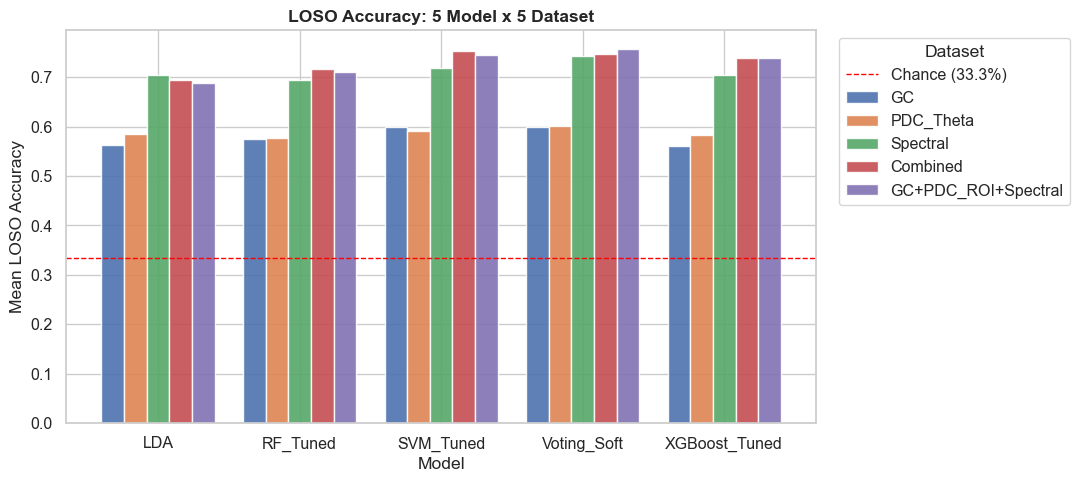

Best LOSO: Voting_Soft + GC+PDC_ROI+Spectral -> 0.7570 +/- 0.0999


In [6]:
DIR_52_FIG = os.path.join(BASE, "5.2_loso_all_models", "figures")
os.makedirs(DIR_52_FIG, exist_ok=True)

pivot = df_summary.pivot(index='Model', columns='Dataset', values='Mean_Accuracy')
pivot = pivot[[c for c in datasets.keys() if c in pivot.columns]]
fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind='bar', ax=ax, width=0.8, alpha=0.9)
ax.axhline(y=1/3, color='red', linestyle='--', linewidth=1, label='Chance (33.3%)')
ax.set_ylabel('Mean LOSO Accuracy')
ax.set_title('LOSO Accuracy: 5 Model x 5 Dataset', fontweight='bold')
ax.legend(title='Dataset', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(os.path.join(DIR_52_FIG, '5.2_loso_summary.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

best = df_summary.iloc[0]
print(f"Best LOSO: {best['Model']} + {best['Dataset']} -> {best['Mean_Accuracy']:.4f} +/- {best['Std_Accuracy']:.4f}")

**Kesimpulan 5.2:** Best LOSO = **Voting_Soft + GC+PDC_ROI+Spectral (75.70% +/- 9.99%)**,
sedikit di atas `SVM_Tuned + Combined (75.26%)` -- konsisten dengan hasil Phase 4 (grouped 5-fold:
75.56%). Std jauh lebih besar dari Phase 4 (~4-5%) karena tiap fold test-nya cuma 1 subjek
(45 sampel) -- wajar untuk LOSO. Lanjut ke **5.3** (analisis per-subjek) dan **5.4** (uji
signifikansi antar dataset).